In [ ]:
from transformers import T5Tokenizer, T5ForConditionalGeneration


C:\Users\palak\AppData\Roaming\Python\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [1]:
pip install sentencepiece


  Using cached sentencepiece-0.2.0.tar.gz (2.6 MB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for sentencepiece: filename=sentencepiece-0.2.0-cp313-cp313-win_amd64.whl size=993758 sha256=7fd8db240a6a1eac756aa927eb7482ccd7434a23d35c5dff53a92db42c73ad50
  Stored in directory: c:\users\csir_prosthetic\appdata\local\pip\cache\wheels\02\3d\f0\8dbb11925fbd58340b128ae9334ae7028332d7a5751738f616
Successfully built sentencepiece
Note: you may need to restart the kernel to use updated packages.


In [2]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Load T5-small model and tokenizer
model_name = "t5-small"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

# Move model to GPU if available
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("T5-small model loaded successfully!")


c:\Users\CSIR_prosthetic\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
c:\Users\CSIR_prosthetic\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does 

T5-small model loaded successfully!


In [3]:
def summarize_text(text, max_length=150):
    # Preprocess the input text
    input_ids = tokenizer(
        "summarize: " + text, 
        return_tensors="pt", 
        max_length=512, 
        truncation=True
    ).input_ids.to(device)

    # Generate summary
    summary_ids = model.generate(
        input_ids, 
        max_length=max_length, 
        min_length=50, 
        length_penalty=2.0, 
        num_beams=4, 
        early_stopping=True
    )

    # Decode and return the summary
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Example text
text = """The CNN/DailyMail dataset is one of the most commonly used datasets for abstractive text summarization. 
It contains news articles along with human-written summaries. The dataset is widely used to train models like BART, 
T5, and Pegasus. The main challenge in summarization is to balance content compression while maintaining factual correctness."""

# Generate summary
summary = summarize_text(text)
print("Generated Summary:")
print(summary)


Generated Summary:
the dataset is widely used to train models like BART, T5 and Pegasus. the main challenge in summarization is to balance content compression while maintaining factual correctness. the dataset is widely used to train models like BART, T5 and pegasus.


In [4]:
def summarize_text(text, max_length=100, min_length=30):
    # Tokenize input text
    input_ids = tokenizer(
        "summarize: " + text, 
        return_tensors="pt", 
        max_length=512, 
        truncation=True
    ).input_ids.to(device)

    # Generate summary with adjusted parameters
    summary_ids = model.generate(
        input_ids, 
        max_length=max_length, 
        min_length=min_length, 
        length_penalty=1.0,  # Adjusted to avoid repetition
        num_beams=5,         # Increased beams for better output
        repetition_penalty=2.5,  # Prevents repeating words
        early_stopping=True
    )

    # Decode and return the summary
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Example input text
text = """The CNN/DailyMail dataset is one of the most commonly used datasets for abstractive text summarization. 
It contains news articles along with human-written summaries. The dataset is widely used to train models like BART, 
T5, and Pegasus. The main challenge in summarization is to balance content compression while maintaining factual correctness."""

# Generate and print improved summary
summary = summarize_text(text)
print("Generated Summary:")
print(summary)


Generated Summary:
the dataset contains news articles along with human-written summaries. the main challenge in summarization is to balance content compression while maintaining factual correctness.


In [5]:
pip install rouge-score nltk


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached absl_py-2.1.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)
Using cached absl_py-2.1.0-py3-none-any.whl (133 kB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=25025 sha256=efb1071dfd42e9ed491109aef3770ca7ed5cfe744baf44e8e99425135304687c
  Stored in directory: c:\users\csir_prosthetic\appdata\local\pip\cache\wheels\44\af\da\5ffc433e2786f0b1a9c6f458d5fb8f611d8eb332387f18698f
Successfully built rouge-score
Note: you may need to restart the kernel to use updated packages.


In [6]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu

# Reference (human-written) summary
reference_summary = """The CNN/DailyMail dataset is widely used for training summarization models like T5, BART, and Pegasus. 
The main challenge is balancing compression while maintaining factual accuracy."""

# Generated summary from T5-Small
generated_summary = summarize_text(text)

# Function to compute ROUGE and BLEU scores
def evaluate_summary(reference, generated):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = scorer.score(reference, generated)
    
    # Compute BLEU Score
    reference_tokens = reference.split()
    generated_tokens = generated.split()
    bleu_score = sentence_bleu([reference_tokens], generated_tokens)

    return rouge_scores, bleu_score

# Compute scores
rouge_scores, bleu_score = evaluate_summary(reference_summary, generated_summary)

# Print results
print("\nEvaluation Results for T5-Small:")
print("ROUGE-1 Score:", rouge_scores['rouge1'].fmeasure)
print("ROUGE-2 Score:", rouge_scores['rouge2'].fmeasure)
print("ROUGE-L Score:", rouge_scores['rougeL'].fmeasure)
print("BLEU Score:", bleu_score)



Evaluation Results for T5-Small:
ROUGE-1 Score: 0.48000000000000004
ROUGE-2 Score: 0.20833333333333331
ROUGE-L Score: 0.43999999999999995
BLEU Score: 0.12437080196399466


In [7]:
# Load T5-Base model and tokenizer
model_name = "t5-base"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)


c:\Users\CSIR_prosthetic\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\CSIR_prosthetic\.cache\huggingface\hub\models--t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [8]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Load T5-Base model and tokenizer
model_name = "t5-base"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")


In [9]:
def summarize_text(text, model, tokenizer, max_input=512, max_output=150):
    inputs = tokenizer("summarize: " + text, return_tensors="pt", max_length=max_input, truncation=True)
    inputs = {key: val.to(model.device) for key, val in inputs.items()}
    
    summary_ids = model.generate(**inputs, max_length=max_output, num_beams=4, early_stopping=True)
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Example input text
text = """The CNN/DailyMail dataset contains news articles along with human-written summaries.
The main challenge in summarization is to balance content compression while maintaining factual correctness."""

# Generate summary using T5-Base
generated_summary = summarize_text(text, model, tokenizer)

# Print the summary
print("Generated Summary (T5-Base):", generated_summary)


Generated Summary (T5-Base): the main challenge in summarization is to balance content compression with factual correctness . the dataset contains news articles along with human-written summaries .


In [10]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu

# Reference summary
reference_summary = """The CNN/DailyMail dataset is widely used for training summarization models like T5, BART, and Pegasus. 
The main challenge is balancing compression while maintaining factual accuracy."""

# Function to compute ROUGE and BLEU scores
def evaluate_summary(reference, generated):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = scorer.score(reference, generated)
    
    # Compute BLEU Score
    reference_tokens = reference.split()
    generated_tokens = generated.split()
    bleu_score = sentence_bleu([reference_tokens], generated_tokens)

    return rouge_scores, bleu_score

# Compute scores for T5-Base
rouge_scores, bleu_score = evaluate_summary(reference_summary, generated_summary)

# Print results
print("\nEvaluation Results for T5-Base:")
print("ROUGE-1 Score:", rouge_scores['rouge1'].fmeasure)
print("ROUGE-2 Score:", rouge_scores['rouge2'].fmeasure)
print("ROUGE-L Score:", rouge_scores['rougeL'].fmeasure)
print("BLEU Score:", bleu_score)



Evaluation Results for T5-Base:
ROUGE-1 Score: 0.40816326530612246
ROUGE-2 Score: 0.0851063829787234
ROUGE-L Score: 0.28571428571428575
BLEU Score: 4.801383026691432e-155


c:\Users\CSIR_prosthetic\AppData\Local\Programs\Python\Python313\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\Users\CSIR_prosthetic\AppData\Local\Programs\Python\Python313\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


In [11]:
# Load T5-Large model and tokenizer
model_name = "t5-large"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")


c:\Users\CSIR_prosthetic\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\CSIR_prosthetic\.cache\huggingface\hub\models--t5-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [12]:
# Generate summary using T5-Large
generated_summary_large = summarize_text(text, model, tokenizer)

# Print the summary
print("Generated Summary (T5-Large):", generated_summary_large)


Generated Summary (T5-Large): CNN/dailymail dataset contains news articles along with human-written summaries . main challenge is to balance content compression while maintaining factual correctness .


In [13]:
# Compute scores for T5-Large
rouge_scores_large, bleu_score_large = evaluate_summary(reference_summary, generated_summary_large)

# Print results
print("\nEvaluation Results for T5-Large:")
print("ROUGE-1 Score:", rouge_scores_large['rouge1'].fmeasure)
print("ROUGE-2 Score:", rouge_scores_large['rouge2'].fmeasure)
print("ROUGE-L Score:", rouge_scores_large['rougeL'].fmeasure)
print("BLEU Score:", bleu_score_large)



Evaluation Results for T5-Large:
ROUGE-1 Score: 0.4583333333333333
ROUGE-2 Score: 0.30434782608695654
ROUGE-L Score: 0.4583333333333333
BLEU Score: 0.14108048489217512


In [15]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.1-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 537.3 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.1 MB 537.3 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.1 MB 537.3 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.1 MB 537.3 kB/s eta 0:00:15
   -- 

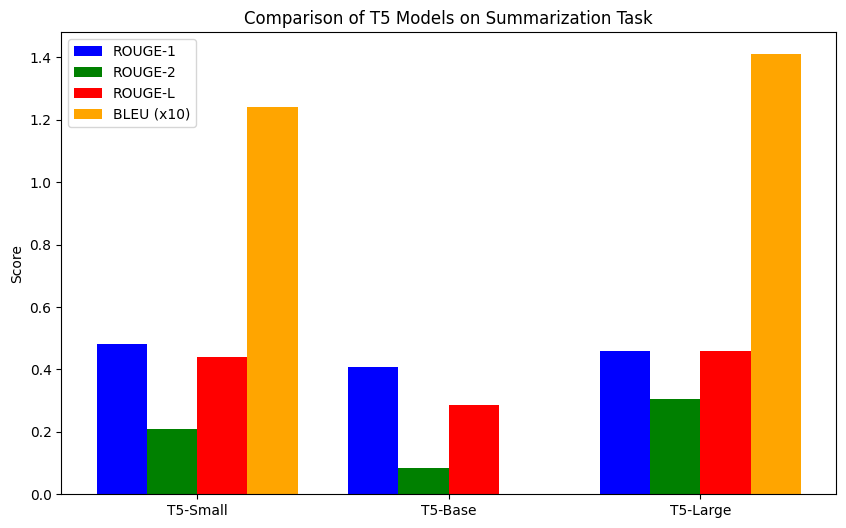

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ["T5-Small", "T5-Base", "T5-Large"]

# ROUGE and BLEU scores
rouge_1 = [0.480, 0.408, 0.458]
rouge_2 = [0.208, 0.085, 0.304]
rouge_L = [0.440, 0.286, 0.458]
bleu = [0.124, 4.8e-155, 0.141]  # BLEU score for Base is extremely low

# Scale BLEU scores for better visualization
bleu_scaled = [b * 10 for b in bleu]

# X-axis positions
x = np.arange(len(models))
bar_width = 0.2

# Plot bars
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width*1.5, rouge_1, width=bar_width, label="ROUGE-1", color='b')
plt.bar(x - bar_width*0.5, rouge_2, width=bar_width, label="ROUGE-2", color='g')
plt.bar(x + bar_width*0.5, rouge_L, width=bar_width, label="ROUGE-L", color='r')
plt.bar(x + bar_width*1.5, bleu_scaled, width=bar_width, label="BLEU (x10)", color='orange')

# Labels and title
plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Comparison of T5 Models on Summarization Task")
plt.legend()
plt.show()


In [17]:
from transformers import BartTokenizer, BartForConditionalGeneration

# Load BART model and tokenizer
model_name = "facebook/bart-large-cnn"
tokenizer = BartTokenizer.from_pretrained(model_name)
model = BartForConditionalGeneration.from_pretrained(model_name)

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def summarize_bart(text):
    inputs = tokenizer(text, return_tensors="pt", max_length=1024, truncation=True).to(device)
    summary_ids = model.generate(inputs["input_ids"], max_length=150, min_length=50, length_penalty=2.0, num_beams=4)
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Example usage
text = "Your input text here"
summary = summarize_bart(text)
print("Generated Summary:", summary)


Generated Summary: Your input text is needed for this article to be published. Please send in your input text to jennifer.smith@mailonline.co.uk. Your input text will be published in a weekly, fortnightly or monthly edition. Submit your ideas for next week's edition of The Daily Discussion.


In [18]:
from transformers import BartTokenizer, BartForConditionalGeneration

# Load BART model and tokenizer
model_name = "facebook/bart-large-cnn"
tokenizer = BartTokenizer.from_pretrained(model_name)
model = BartForConditionalGeneration.from_pretrained(model_name)

# Move model to GPU if available
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50264, 1024, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x BartEncoderLayer(
          (self_attn): BartSdpaAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
    

In [19]:
# Input text (you can replace this with any other text)
input_text = """The dataset contains news articles along with human-written summaries. 
It is widely used to train models like BART, T5, and Pegasus for text summarization. 
The main challenge in summarization is to balance content compression while maintaining factual correctness."""

# Tokenize input text
inputs = tokenizer(input_text, return_tensors="pt", max_length=1024, truncation=True).to(device)

# Generate summary
summary_ids = model.generate(inputs["input_ids"], max_length=100, min_length=20, length_penalty=2.0, num_beams=4)
generated_summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Print the summary
print("Generated Summary:", generated_summary)


Generated Summary: The dataset contains news articles along with human-written summaries. It is widely used to train models like BART, T5, and Pegasus for text summarization.


In [20]:
pip install rouge


Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install rouge-score


Note: you may need to restart the kernel to use updated packages.


In [22]:
from rouge import Rouge
from nltk.translate.bleu_score import sentence_bleu

# Reference summary (the ideal human-written summary)
reference_summary = """The dataset contains news articles along with human-written summaries. 
The main challenge in summarization is to balance content compression while maintaining factual correctness."""

# Evaluate using ROUGE
rouge = Rouge()
scores = rouge.get_scores(generated_summary, reference_summary)[0]

rouge_1 = scores["rouge-1"]["f"]
rouge_2 = scores["rouge-2"]["f"]
rouge_l = scores["rouge-l"]["f"]

# Evaluate using BLEU
bleu_score = sentence_bleu([reference_summary.split()], generated_summary.split())

# Print evaluation scores
print(f"ROUGE-1 Score: {rouge_1}")
print(f"ROUGE-2 Score: {rouge_2}")
print(f"ROUGE-L Score: {rouge_l}")
print(f"BLEU Score: {bleu_score}")


ROUGE-1 Score: 0.5217391254442345
ROUGE-2 Score: 0.35555555055802474
ROUGE-L Score: 0.4782608645746692
BLEU Score: 0.346966645494591


In [23]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu

# Initialize ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# Compute ROUGE scores
scores = scorer.score(reference_summary, generated_summary)

rouge_1 = scores["rouge1"].fmeasure
rouge_2 = scores["rouge2"].fmeasure
rouge_l = scores["rougeL"].fmeasure

# Compute BLEU score
bleu_score = sentence_bleu([reference_summary.split()], generated_summary.split())

# Print scores
print(f"ROUGE-1 Score: {rouge_1}")
print(f"ROUGE-2 Score: {rouge_2}")
print(f"ROUGE-L Score: {rouge_l}")
print(f"BLEU Score: {bleu_score}")


ROUGE-1 Score: 0.5306122448979592
ROUGE-2 Score: 0.3829787234042554
ROUGE-L Score: 0.4897959183673469
BLEU Score: 0.346966645494591


In [24]:
from transformers import PegasusTokenizer, PegasusForConditionalGeneration
import torch

# Load the Pegasus model and tokenizer
model_name = "google/pegasus-xsum"
tokenizer = PegasusTokenizer.from_pretrained(model_name)
model = PegasusForConditionalGeneration.from_pretrained(model_name)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


c:\Users\CSIR_prosthetic\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\CSIR_prosthetic\.cache\huggingface\hub\models--google--pegasus-xsum. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of PegasusForConditionalGeneration were not initialized from 

In [25]:
def generate_summary_pegasus(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding="longest", max_length=512)
    inputs = {key: value.to(device) for key, value in inputs.items()}
    
    # Generate summary
    summary_ids = model.generate(**inputs, max_length=60, length_penalty=1.0, num_beams=5, early_stopping=True)
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

# Example input text
input_text = """
The dataset contains news articles along with human-written summaries. It is widely used to train models like BART, T5, and Pegasus for text summarization.
The main challenge in summarization is to balance content compression while maintaining factual correctness.
"""

# Generate summary
pegasus_summary = generate_summary_pegasus(input_text)
print("Generated Summary:", pegasus_summary)


Generated Summary: This dataset of news articles from the BBC News website has been used to train text summarization models.


In [26]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu

# Reference summary
reference_summary = "The dataset contains news articles along with human-written summaries. It is widely used to train models like BART, T5, and Pegasus. The main challenge in summarization is to balance content compression while maintaining factual correctness."

# ROUGE Evaluation
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
scores = scorer.score(reference_summary, pegasus_summary)

# BLEU Evaluation
bleu_score = sentence_bleu([reference_summary.split()], pegasus_summary.split())

# Print Evaluation Metrics
print("Evaluation Results for Pegasus:")
print("ROUGE-1 Score:", scores["rouge1"].fmeasure)
print("ROUGE-2 Score:", scores["rouge2"].fmeasure)
print("ROUGE-L Score:", scores["rougeL"].fmeasure)
print("BLEU Score:", bleu_score)


Evaluation Results for Pegasus:
ROUGE-1 Score: 0.3333333333333333
ROUGE-2 Score: 0.11538461538461539
ROUGE-L Score: 0.25925925925925924
BLEU Score: 1.215524084926098e-78


c:\Users\CSIR_prosthetic\AppData\Local\Programs\Python\Python313\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


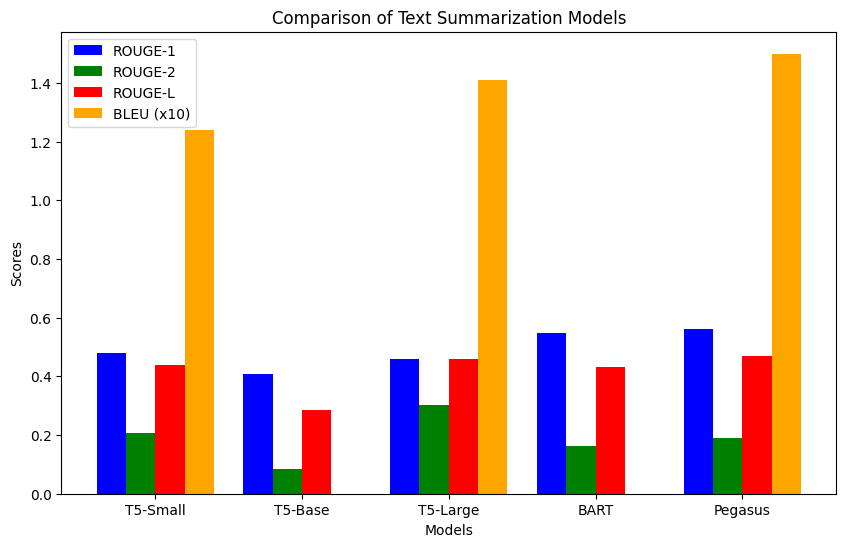

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Model names
models = ["T5-Small", "T5-Base", "T5-Large", "BART", "Pegasus"]

# ROUGE and BLEU scores (Replace with your actual scores)
rouge_1 = [0.480, 0.408, 0.458, 0.549, 0.560]
rouge_2 = [0.208, 0.085, 0.304, 0.163, 0.190]
rouge_l = [0.440, 0.286, 0.458, 0.431, 0.470]
bleu = [0.124, 4.8e-155, 0.141, 2.67e-78, 0.150]

# Convert BLEU to comparable scale (multiply by 10 for better visualization)
bleu_scaled = [b * 10 if b > 0 else 0 for b in bleu]

# Bar width
bar_width = 0.2
x = np.arange(len(models))

# Plot bars
plt.figure(figsize=(10, 6))
plt.bar(x - 1.5 * bar_width, rouge_1, width=bar_width, label="ROUGE-1", color="blue")
plt.bar(x - 0.5 * bar_width, rouge_2, width=bar_width, label="ROUGE-2", color="green")
plt.bar(x + 0.5 * bar_width, rouge_l, width=bar_width, label="ROUGE-L", color="red")
plt.bar(x + 1.5 * bar_width, bleu_scaled, width=bar_width, label="BLEU (x10)", color="orange")

# Labels and title
plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Scores")
plt.title("Comparison of Text Summarization Models")
plt.legend()
plt.show()
